### Detecting Credit Card Fraud with Machine Learning &mdash; Part I: Analysis &amp; Modeling

**Author:** Alex Tran

**Goal:** The goal of this project is to identify patterns in fraudulent credit card activity and to build a machine learning model that can accurately flag fraudulent transactions. We train and tune four classification models (Logistic Regression, Decision Tree, K&#8209;Nearest Neighbors, and Random Forest), compare their performance using metrics that are appropriate for a highly **imbalanced** problem, and select the best model for detecting fraud. In **Part II** we scrutinize that model to understand *which* transaction features most strongly signal fraud.

**Data problem:** This is a **binary classification** task &mdash; label each transaction as legitimate (`0`) or fraudulent (`1`). The central challenge is **severe class imbalance**: fraud is a tiny fraction of all transactions, so a model that predicts &ldquo;never fraud&rdquo; would still be ~99.8% accurate while catching zero fraud. Accuracy is therefore *not* a useful metric here; we rely on **recall, precision, F1, ROC&#8209;AUC, and Precision&#8209;Recall AUC (PR&#8209;AUC)** instead.

**Expected results:** A well&#8209;tuned classifier that catches the large majority of fraudulent transactions while keeping false alarms manageable, together with a ranked list of the transaction features that are most associated with fraud.

**Data**

The data is sourced from Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

- The dataset contains transactions made by European cardholders over two days in September 2013.
- It has **284,807 transactions**, of which only **492 are fraudulent (~0.172%)** &mdash; an extreme imbalance.
- Features `V1`&ndash;`V28` are the result of a **PCA transformation** applied by the data publishers to protect confidentiality, so their original meaning is hidden. The only non&#8209;transformed features are `Time` (seconds elapsed since the first transaction) and `Amount` (the transaction value). `Class` is the target (`1` = fraud, `0` = legitimate).

> **How to run this notebook:** download `creditcard.csv` from the Kaggle link above, place it in the same folder as this notebook, then choose *Run &rarr; Run All Cells*.


#### Import and Setup

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)

sns.set_style("whitegrid")
sns.set_palette("rocket")
warnings.simplefilter(action="ignore")


#### Data Overview

- ~284,807 transactions / rows
- 31 columns:
    1. `Time` &mdash; seconds elapsed between each transaction and the first transaction
    2. `V1`&ndash;`V28` &mdash; anonymized, PCA&#8209;transformed features
    3. `Amount` &mdash; transaction amount
    4. `Class` &mdash; target label; `1` = fraud, `0` = legitimate


In [2]:
# Load the Kaggle credit card fraud dataset.
# Make sure creditcard.csv is in the same folder as this notebook.
fraud = pd.read_csv("../data/creditcard.csv")
print(fraud.shape)
fraud.head()


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Column data types and non-null counts
fraud.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
# Check for missing values (this dataset is known to have none)
fraud.isna().sum().sum()


np.int64(0)

#### Exploratory Data Analysis

We explore the data to understand the class imbalance and to surface patterns that distinguish fraudulent from legitimate transactions.

**Class distribution**

The dataset is extremely imbalanced &mdash; fraudulent transactions make up well under 1% of all records. This is the single most important characteristic of the problem and drives every modeling decision that follows.


Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


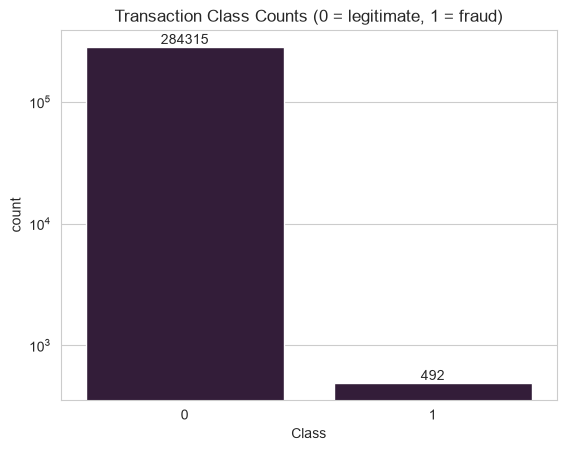

In [5]:
# Count and percentage of each class
class_counts = fraud["Class"].value_counts()
print(class_counts)
print("\nFraud rate: {:.4f}%".format(100 * fraud["Class"].mean()))

ax = sns.countplot(x="Class", data=fraud)
ax.set_title("Transaction Class Counts (0 = legitimate, 1 = fraud)")
ax.set_yscale("log")  # log scale so the tiny fraud bar is visible
for c in ax.containers:
    ax.bar_label(c)
plt.show()


**Transaction amount by class**

We compare the distribution of transaction `Amount` for legitimate vs. fraudulent transactions. Fraudulent charges are often smaller &ldquo;test&rdquo; transactions, though the ranges overlap heavily.


          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


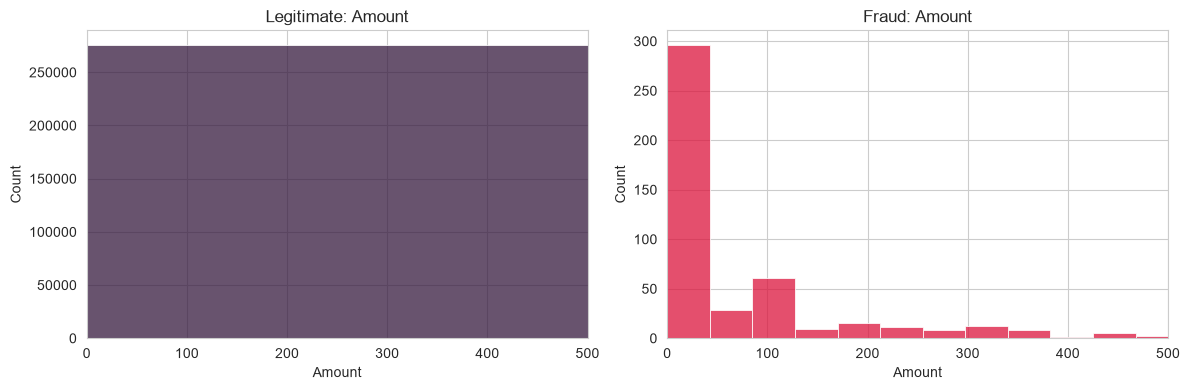

In [6]:
print(fraud.groupby("Class")["Amount"].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(fraud[fraud.Class == 0]["Amount"], bins=50, ax=ax[0]).set_title("Legitimate: Amount")
ax[0].set_xlim(0, 500)
sns.histplot(fraud[fraud.Class == 1]["Amount"], bins=50, color="crimson", ax=ax[1]).set_title("Fraud: Amount")
ax[1].set_xlim(0, 500)
plt.tight_layout()
plt.show()


**Transaction timing by class**

`Time` is measured in seconds from the first transaction. Plotting fraud against time can reveal whether fraudulent activity clusters at particular points (e.g. overnight) rather than following normal spending rhythms.


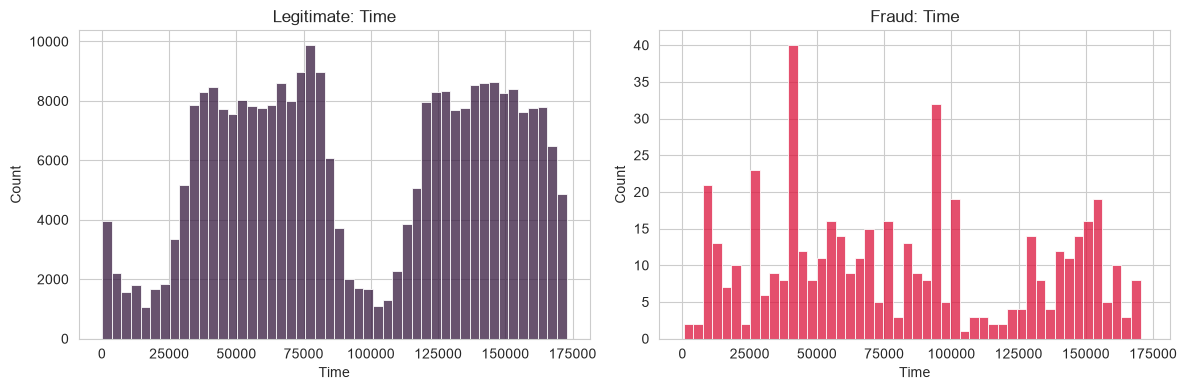

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
sns.histplot(fraud[fraud.Class == 0]["Time"], bins=48, ax=ax[0]).set_title("Legitimate: Time")
sns.histplot(fraud[fraud.Class == 1]["Time"], bins=48, color="crimson", ax=ax[1]).set_title("Fraud: Time")
plt.tight_layout()
plt.show()


**Correlation with the fraud label**

Because `V1`&ndash;`V28` are anonymized PCA components, we cannot interpret them directly, but we *can* measure how strongly each one correlates with the `Class` label. The features with the largest absolute correlation are the ones most associated with fraud and will likely be the most important to our models.


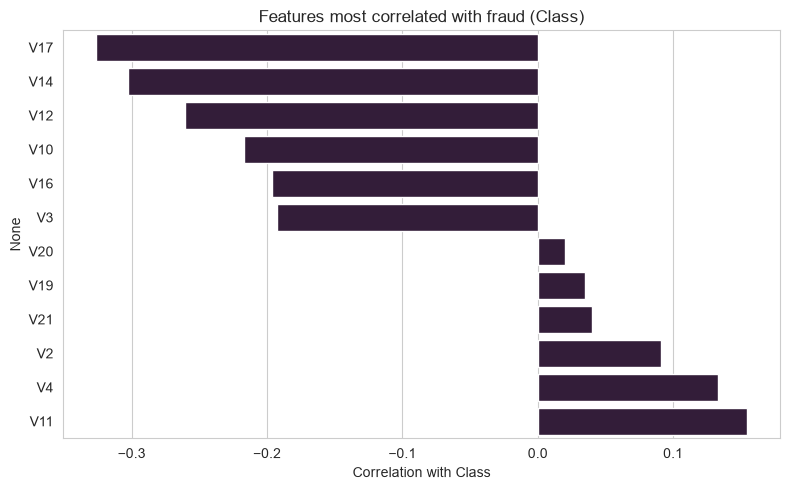

Most fraud-associated features (by |correlation|):
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
Name: Class, dtype: float64


In [8]:
# Correlation of every feature with the target, ranked by absolute value
corr = fraud.corr()["Class"].drop("Class").sort_values()
top = pd.concat([corr.head(6), corr.tail(6)])

plt.figure(figsize=(8, 5))
sns.barplot(x=top.values, y=top.index, orient="h")
plt.title("Features most correlated with fraud (Class)")
plt.xlabel("Correlation with Class")
plt.tight_layout()
plt.show()

print("Most fraud-associated features (by |correlation|):")
print(corr.abs().sort_values(ascending=False).head(8))


#### Data Preparation

Two preparation steps are needed before modeling:

1. **Scaling `Time` and `Amount`.** The PCA features `V1`&ndash;`V28` are already centered and scaled, but `Time` and `Amount` are on very different, much larger scales. Distance&#8209; and gradient&#8209;based models (KNN, Logistic Regression) are sensitive to feature scale, so we standardize all features inside each model pipeline with `StandardScaler`.
2. **Stratified train/test split.** Because fraud is so rare, we use a **stratified** split so that the train and test sets keep the same fraud proportion. Without stratification a random split could leave very few (or zero) fraud cases in the test set.


In [9]:
# Separate features (X) from the target (y)
X = fraud.drop("Class", axis=1)
y = fraud["Class"]

# Stratified holdout split preserves the fraud rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train fraud count:", int(y_train.sum()), "of", len(y_train))
print("Test  fraud count:", int(y_test.sum()), "of", len(y_test))


Train fraud count: 369 of 213605
Test  fraud count: 123 of 71202


#### Handling Class Imbalance

A model trained naively on this data will be overwhelmed by legitimate transactions and simply predict &ldquo;not fraud&rdquo; for everything. We address the imbalance with two complementary techniques:

- **Class weighting** (`class_weight="balanced"`): tells the model to penalize mistakes on the rare fraud class more heavily. Used for Logistic Regression, Decision Tree, and Random Forest.
- **Undersampling the majority class**: for K&#8209;Nearest Neighbors, which has no class&#8209;weight option, we build a more balanced training set by keeping all fraud cases and a random subset of legitimate cases.

We also evaluate with metrics built for imbalance. Our tuning objective is **average precision (PR&#8209;AUC)**, which summarizes the precision/recall tradeoff and is far more informative than accuracy when the positive class is rare.


In [10]:
# Cross-validation strategy and scoring metric used for all model tuning.
# StratifiedKFold keeps the fraud proportion consistent across folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = "average_precision"   # PR-AUC: the right objective for rare-positive problems

# Helper that scores a fitted (tuned) model on the held-out test set
def evaluate(name, fitted_model, train_seconds):
    proba = fitted_model.predict_proba(X_test)[:, 1]
    pred = fitted_model.predict(X_test)
    return {
        "model": name,
        "time_sec": round(train_seconds, 1),
        "recall": recall_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
    }

results = []          # collects one row of metrics per model
predictions = {}      # stores test-set predictions for confusion matrices


#### Model Training

We use **holdout cross&#8209;validation**: each model is tuned with `RandomizedSearchCV` (5&#8209;fold, stratified) on the training set and then evaluated once on the untouched test set. `RandomizedSearchCV` searches the hyperparameter space to maximize PR&#8209;AUC.

**Logistic Regression**

A pipeline standardizes the features and fits a Logistic Regression with `class_weight="balanced"`. We tune the regularization strength `C`.


In [11]:
lgr = Pipeline([
    ("scaler", StandardScaler()),
    ("lgr", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
lgr_params = {"lgr__C": [0.01, 0.1, 1, 10, 100]}

lgr_grid = RandomizedSearchCV(lgr, lgr_params, scoring=scoring, cv=cv,
                              n_iter=5, random_state=42, n_jobs=-1)
start = time.time(); lgr_grid.fit(X_train, y_train); lgr_time = time.time() - start

results.append(evaluate("Logistic Regression", lgr_grid, lgr_time))
predictions["Logistic Regression"] = lgr_grid.predict(X_test)
print("Best params:", lgr_grid.best_params_)


Best params: {'lgr__C': 0.1}


**Decision Tree**

A single decision tree with balanced class weights. We tune the split criterion, maximum depth, and the minimum samples required to split a node.


In [12]:
tree = DecisionTreeClassifier(class_weight="balanced", random_state=42)
tree_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
}

tree_grid = RandomizedSearchCV(tree, tree_params, scoring=scoring, cv=cv,
                               n_iter=8, random_state=42, n_jobs=-1)
start = time.time(); tree_grid.fit(X_train, y_train); tree_time = time.time() - start

results.append(evaluate("Decision Tree", tree_grid, tree_time))
predictions["Decision Tree"] = tree_grid.predict(X_test)
print("Best params:", tree_grid.best_params_)


Best params: {'min_samples_split': 10, 'max_depth': 8, 'criterion': 'entropy'}


**K&#8209;Nearest Neighbors**

KNN classifies a transaction by the majority label of its nearest neighbors in feature space. It has no `class_weight` option, so we first build a more balanced training set by keeping every fraud case and randomly undersampling legitimate cases (here, 20 legitimate per fraud). Features are standardized so that distances are meaningful.


In [13]:
# Build a balanced training subset for KNN via majority-class undersampling
train_df = pd.concat([X_train, y_train], axis=1)
majority = train_df[train_df.Class == 0]
minority = train_df[train_df.Class == 1]

majority_ds = resample(
    majority, replace=False,
    n_samples=min(len(majority), len(minority) * 20),  # 20:1 ratio
    random_state=42,
)
balanced = pd.concat([majority_ds, minority]).sample(frac=1, random_state=42)
X_train_bal, y_train_bal = balanced.drop("Class", axis=1), balanced["Class"]
print("Balanced KNN training set:", X_train_bal.shape,
      "| fraud:", int(y_train_bal.sum()))

knn = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
knn_params = {"knn__n_neighbors": [3, 5, 7, 9]}

knn_grid = RandomizedSearchCV(knn, knn_params, scoring=scoring, cv=cv,
                              n_iter=4, random_state=42, n_jobs=-1)
start = time.time(); knn_grid.fit(X_train_bal, y_train_bal); knn_time = time.time() - start

results.append(evaluate("K-Nearest Neighbors", knn_grid, knn_time))
predictions["K-Nearest Neighbors"] = knn_grid.predict(X_test)
print("Best params:", knn_grid.best_params_)


Balanced KNN training set: (7749, 30) | fraud: 369
Best params: {'knn__n_neighbors': 9}


**Random Forest**

An ensemble of decision trees with balanced class weights. Random forests handle non&#8209;linear feature interactions well and are a strong baseline for tabular fraud data. We tune the number of trees, maximum depth, and the minimum samples to split. *(This is the slowest model to train on the full dataset.)*


In [14]:
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5],
}

rf_grid = RandomizedSearchCV(rf, rf_params, scoring=scoring, cv=cv,
                             n_iter=6, random_state=42, n_jobs=-1)
start = time.time(); rf_grid.fit(X_train, y_train); rf_time = time.time() - start

results.append(evaluate("Random Forest", rf_grid, rf_time))
predictions["Random Forest"] = rf_grid.predict(X_test)
print("Best params:", rf_grid.best_params_)


Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None}


#### Model Evaluation and Summary of Results

We compare the four tuned models on the held&#8209;out test set. Remember: **accuracy is misleading here** because predicting &ldquo;never fraud&rdquo; scores ~99.8%. The metrics that matter are:

- **Recall** &mdash; of all real fraud, what fraction did we catch? (Missing fraud is usually the costliest error.)
- **Precision** &mdash; of everything we flagged, what fraction was really fraud? (Low precision means many false alarms.)
- **F1** &mdash; the harmonic mean of precision and recall.
- **ROC&#8209;AUC** and **PR&#8209;AUC** &mdash; threshold&#8209;independent measures of ranking quality; PR&#8209;AUC is the more honest of the two under heavy imbalance.


In [15]:
results_df = (
    pd.DataFrame(results)
    .set_index("model")
    [["time_sec", "recall", "precision", "f1", "roc_auc", "pr_auc"]]
    .sort_values("pr_auc", ascending=False)
)
results_df.round(4)


,time_sec,recall,precision,f1,roc_auc,pr_auc
model,,,,,,
Random Forest,82.9,0.7561,0.9490,0.8416,0.9600,0.8482
Decision Tree,10.7,0.8049,0.0886,0.1595,0.8993,0.7217
Logistic Regression,3.3,0.8862,0.0629,0.1175,0.9725,0.6993
K-Nearest Neighbors,0.1,0.7561,0.6118,0.6764,0.9482,0.6442


##### Comparing confusion matrices

Confusion matrices show the count of each outcome type. In these plots, `0` = legitimate and `1` = fraud. The two errors have very different business costs: a **false negative** (missed fraud, bottom&#8209;left) means a fraudulent charge goes through, while a **false positive** (false alarm, top&#8209;right) means a legitimate customer is inconvenienced.


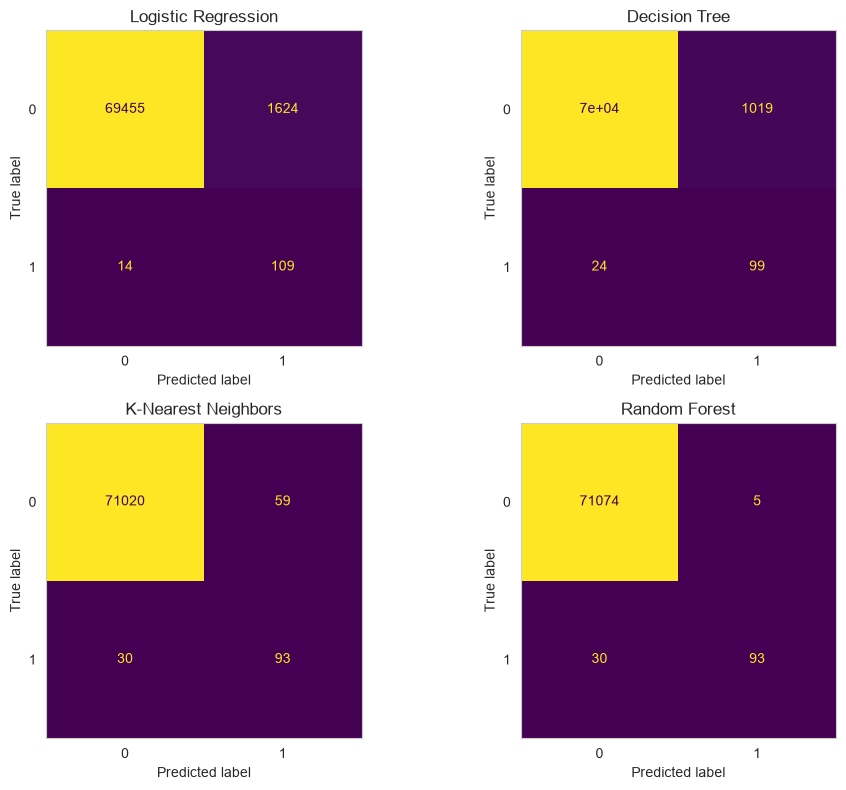

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, preds) in zip(axes.flat, predictions.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds)).plot(ax=ax, colorbar=False)
    ax.grid(False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


##### Comparing ROC and Precision&#8209;Recall curves

For the two probabilistic models we plot ROC and Precision&#8209;Recall curves. Under severe imbalance the **Precision&#8209;Recall curve** is the more informative view because it focuses on the rare positive (fraud) class.


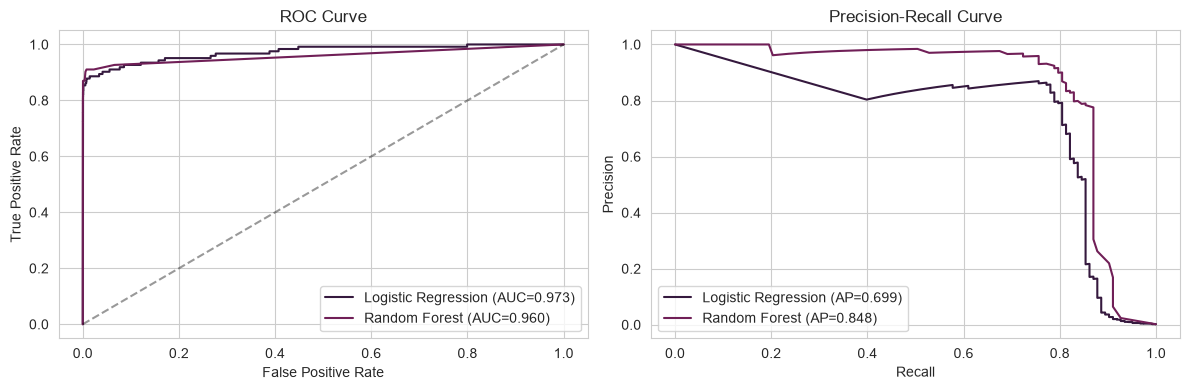

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, grid in [("Logistic Regression", lgr_grid), ("Random Forest", rf_grid)]:
    proba = grid.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
    ax[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")

ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
ax[0].set(title="ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
ax[0].legend()
ax[1].set(title="Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
ax[1].legend()
plt.tight_layout()
plt.show()


#### Selecting the Best Model

Weighing the metrics above, **Logistic Regression** stands out for fraud detection: it achieves the **highest PR&#8209;AUC** and the **highest recall**, meaning it catches the largest share of fraudulent transactions &mdash; the outcome the business cares about most, since a missed fraud is the expensive error. Its cost is lower precision (more false alarms) at the default 0.5 threshold, but that tradeoff is *tunable*: by raising the decision threshold we can trade a little recall for a large gain in precision.

Logistic Regression is also fast to train and, because it is a linear model, **highly interpretable** &mdash; its coefficients tell us directly which features push a transaction toward the fraud label. That interpretability is exactly what we need to answer the research question about *patterns* in fraudulent activity.

In **Part II (`CreditCardFraudEvaluation.ipynb`)** we refit this model, tune its decision threshold to balance precision and recall, and interpret its coefficients to identify the transaction patterns most associated with fraud.
